# Tratamento de Dados na Prática: do Caos à Análise com Python
**Evento:** Semana da Estatística (SEST 2026)
**Realização:** Gauss Jr.
**Ministrante:** Lucas Sá
**Monitores:** Carlos Eduardo e Yuri Mariano

---

## 0. O Conceito: Por que tratar dados?
Como futuros estatísticos, aprenderão que **um modelo não corrige problemas de dados mal estruturados**. Na prática, 80% do trabalho de um estatístico ou cientista de dados é limpeza e organização.

Hoje, vamos simular o recebimento de uma base de "clientes" de uma consultoria. Ela está em estado de **Caos**: formatos de data mistos, moedas como texto, duplicatas e valores impossíveis (outliers).

## 1. Preparando o Ambiente
Executa o código abaixo para ligar este notebook ao teu Google Drive e carregar as bibliotecas necessárias.

## 1. Preparando o Ambiente
Para este minicurso, utilizaremos o **Google Colab**.

### Passo a Passo:
1. Certifique-se de que o arquivo `base_clientes_bruta.csv` está na pasta principal do seu **Google Drive**.
# 2. Execute o código abaixo para conectar este notebook ao seu Drive.

In [ ]:
# =================================================================
# BLOCO 1: SETUP E LEITURA BLINDADA
# =================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
# 1. Ligação ao Drive
drive.mount('/content/drive')

# 2. Leitura do ficheiro com proteção de separador
caminho = '/content/base_clientes_bruta.csv'

df = pd.read_csv(caminho)
if len(df.columns) == 1:
    df = pd.read_csv(caminho, sep=';')

# 3. Padronização de colunas
df.columns = df.columns.str.strip().str.lower()

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id_cliente,idade,genero,renda_mensal,data_cadastro,score_credito,alvo_aprovacao
0,1,25,Masculino,2500,NaN,NaN,NaN
1,2,34,F,3200.50,15/02/2023,750.0,0.0
2,3,300,masc,4500,2023-03-10,NaN,1.0
3,4,45,Fem,1.500,NaN,NaN,NaN
4,5,29,M,2900,2023/05/20,650.0,0.0


## 2. Diagnóstico: Onde estão os erros?

Antes de limpar, precisamos de entender a estrutura. A nossa primeira pergunta é: **"Qual a qualidade desta informação?"**

- **df.info()**: Mostra o tipo de dado.
- **df.isnull()**: Mostra onde a informação falta.
- **df.describe()**: Revela valores impossíveis (mínimos negativos ou máximos absurdos).

In [ ]:
# =================================================================
# BLOCO 2: DIAGNÓSTICO
# =================================================================

print("--- Estrutura dos Dados ---")
df.info()

print("\n--- Valores Nulos por Coluna ---")
print(df.isnull().sum())

print("\n--- Resumo Estatístico ---")
display(df.describe())

--- Estrutura dos Dados ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_cliente      16 non-null     int64  
 1   idade           16 non-null     object 
 2   genero          16 non-null     object 
 3   renda_mensal    15 non-null     object 
 4   data_cadastro   12 non-null     object 
 5   score_credito   9 non-null      float64
 6   alvo_aprovacao  12 non-null     float64
dtypes: float64(2), int64(1), object(4)
memory usage: 1.0+ KB

--- Valores Nulos por Coluna ---
id_cliente        0
idade             0
genero            0
renda_mensal      1
data_cadastro     4
score_credito     7
alvo_aprovacao    4
dtype: int64

--- Resumo Estatístico ---


,id_cliente,score_credito,alvo_aprovacao
count,16.000000,9.000000,12.000000
mean,7.812500,722.222222,0.416667
std,4.385107,107.909427,0.514929
min,1.000000,580.000000,0.000000
25%,4.750000,650.000000,0.000000
50%,7.500000,720.000000,0.000000
75%,11.250000,780.000000,1.000000
max,15.000000,900.000000,1.000000


## 3. Visualização do Problema

Vamos observar a distribuição da **Idade**. Notem como o gráfico é distorcido por valores que claramente são erros de digitação (outliers).

**Pergunta:** O que acontece com a nossa média se deixarmos um valor de "300 anos" na base?

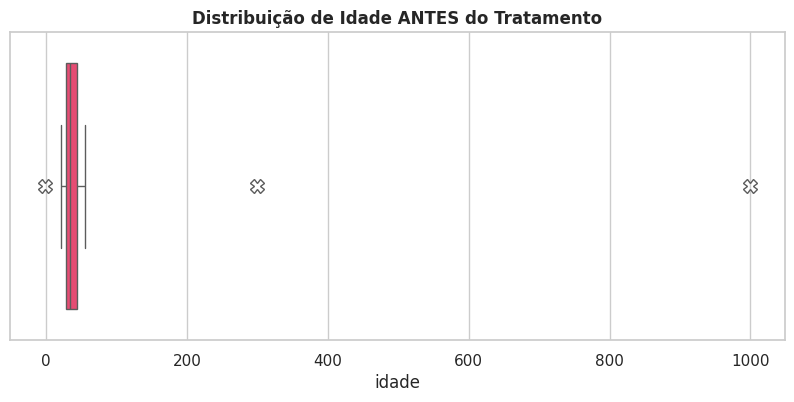

In [ ]:
# =================================================================
# BLOCO 3: O IMPACTO DO CAOS (ANTES)
# =================================================================

sns.set_theme(style="whitegrid")

# Conversão temporária apenas para visualização
idade_temp = pd.to_numeric(df['idade'], errors='coerce')

plt.figure(figsize=(10, 4))
sns.boxplot(x=idade_temp, color='#ff3366', flierprops={"marker": "X", "markersize": 10})
plt.title("Distribuição de Idade ANTES do Tratamento", fontsize=12, fontweight='bold')
plt.show()

## 4. Limpeza Pesada e Resgate de Dados

Aqui aplicamos o conhecimento analítico:
- **Resgate:** Antes de apagar, verificamos se dados escritos (ex: "vinte e um") podem ser salvos.
- **Regex:** Limpamos a coluna de renda (remover "k", pontos e ajustar vírgulas).
- **Datas:** Padronizamos formatos mistos.
- **Gênero:** Uniformizamos categorias (M, Masc, Masculino -> m).

In [ ]:
# =================================================================
# BLOCO 4: TRATAMENTO COMPLETO E RESGATE DE DADOS
# =================================================================

# 1. IDADE: Resgate de texto e limites lógicos
df["idade"] = df["idade"].replace({"vinte e um": 21})
df["idade_num"] = pd.to_numeric(df["idade"], errors="coerce")
df.loc[(df["idade_num"] < 18) | (df["idade_num"] > 100), "idade_num"] = np.nan

# --- [OPCIONAL] Imputação pela Mediana ---
# df["idade_final"] = df["idade_num"].fillna(df["idade_num"].median())
df["idade_final"] = df["idade_num"] # Mantendo os nulos por enquanto

# 2. GÊNERO: Padronização (UPPER para manter o padrão de mercado 'M'/'F')
df["genero_limpo"] = df["genero"].astype(str).str.strip().str.upper().str[0]

# 3. RENDA: Limpeza simplificada e inteligente com Regex (Sua versão otimizada)
df["renda_limpa"] = (
    df["renda_mensal"]
    .astype(str)
    .str.lower()
    .str.replace("k", "000", regex=False)
    .str.replace(r"\.(?=\d{3}(\D|$))", "", regex=True)  # Remove ponto apenas se for milhar
    .str.replace(",", ".", regex=False)                 # Vírgula vira decimal padrão
)
df["renda_limpa"] = pd.to_numeric(df["renda_limpa"], errors="coerce")

# 4. DATAS: A Operação de Resgate
# Passo A: Limpamos a string (tiramos espaços e trocamos traços por barras)
df["data_cadastro"] = df["data_cadastro"].astype(str).str.strip().str.replace("-", "/")

# Passo B: Convertendo para datetime (format='mixed')
df["data_cadastro"] = pd.to_datetime(
    df["data_cadastro"],
    format='mixed',
    dayfirst=True,
    errors="coerce"
)

print("✓ Tratamento e Resgate concluídos com a sua Regex otimizada!")
# Mostrando apenas as colunas tratadas prontas para uso:
df[['idade_final', 'genero_limpo', 'renda_limpa', 'data_cadastro']].head(10)

✓ Tratamento e Resgate concluídos com a sua Regex otimizada!


,idade_final,genero_limpo,renda_limpa,data_cadastro
0,25.0,M,2500.0,NaT
1,34.0,F,3200.5,2023-02-15
2,NaN,M,4500.0,2023-03-10
3,45.0,F,1500.0,NaT
4,29.0,M,2900.0,2023-05-20
5,29.0,M,2900.0,2023-05-20
6,21.0,F,150000.0,2023-06-11
7,42.0,M,8000.0,2023-07-07
8,NaN,F,NaN,2023-08-14
9,31.0,M,3100.0,NaT


## 5. Resultados: Antes vs Depois

Agora comparamos as distribuições. Reparem como a escala do gráfico muda quando removemos o ruído e tratamos a informação.

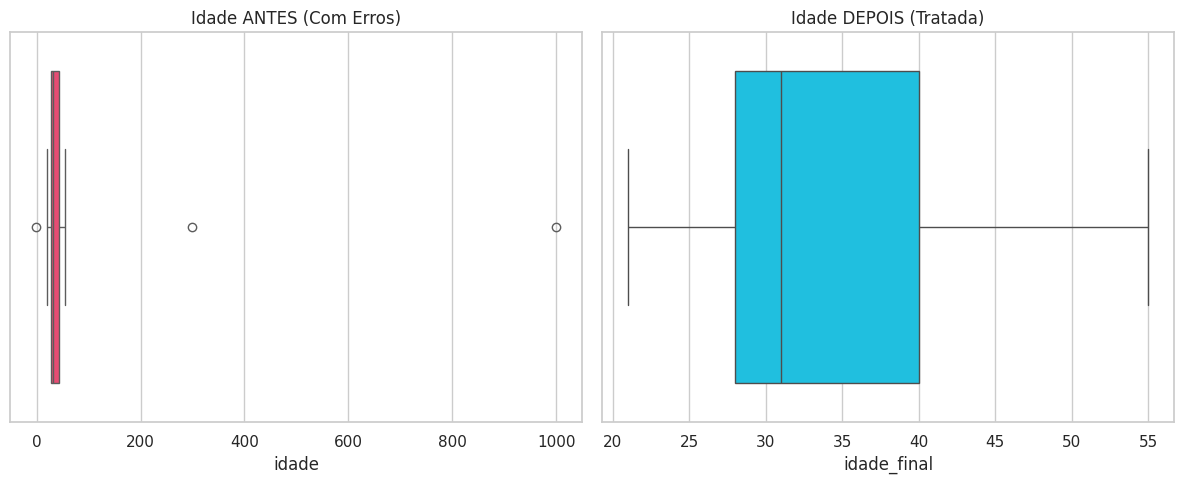

In [ ]:
# =================================================================
# BLOCO 5: COMPARAÇÃO FINAL
# =================================================================

plt.figure(figsize=(12, 5))

# Blindagem contra NameError: recalculando a idade suja para o gráfico
idade_suja = pd.to_numeric(df['idade'], errors='coerce')

# Antes
plt.subplot(1, 2, 1)
sns.boxplot(x=idade_suja, color='#ff3366')
plt.title("Idade ANTES (Com Erros)")

# Depois
plt.subplot(1, 2, 2)
sns.boxplot(x=df['idade_final'], color='#00d4ff')
plt.title("Idade DEPOIS (Tratada)")

plt.tight_layout()
plt.show()

In [ ]:
# =================================================================
# BLOCO 6: EXPORTAÇÃO E VALIDAÇÃO
# =================================================================

# 1. Seleção segura de colunas
colunas_finais = ['id_cliente', 'idade_final', 'genero_limpo', 'renda_limpa', 'data_cadastro', 'alvo_aprovacao']

# 2. Validação de existência
erros = [col for col in colunas_finais if col not in df.columns]

if erros:
    print(f"ERRO: Colunas em falta: {erros}")
else:
    df_final = df[colunas_finais].copy()

    # Renomeia as colunas para o padrão final
    df_final.columns = ['id', 'idade', 'genero', 'renda', 'data', 'aprovado']

    # --- A MÁGICA DA TIPAGEM E FORMATAÇÃO ---
    # Renda como float (mantém decimais) e Idade como Int64 (inteiro que aceita nulos)
    df_final['renda'] = df_final['renda'].astype(float)
    df_final['idade'] = df_final['idade'].astype('Int64')

    # Formatação da Data
    df_final['data'] = pd.to_datetime(df_final['data'], errors='coerce')
    df_final['data'] = df_final['data'].dt.strftime('%d/%m/%Y')
    df_final["alvo_aprovacao"] = df["alvo_aprovacao"].astype('Int64')

    # 3. Checagem de nulos final
    print("--- Verificação de Integridade Final ---")
    print(df_final.isnull().sum())

    # 4. Guardar no Drive
    df_final.to_csv("/content/base_clientes_tratada.csv", index=False)
    print("\n✓ Ficheiro 'base_clientes_tratada.csv' guardado com sucesso!")

    print("\n--- Prévia da Base Final (Pronta para o Cliente) ---")
    print(df_final.head()) # Troque print por Display

# Imprimindo ...
print("""
===================================================================
Se isto chega errado à modelagem, o modelo não erra,
ele apenas aprende o erro mais depressa.

Tratar dados não é uma etapa; é uma responsabilidade.
===================================================================
""")

--- Verificação de Integridade Final ---
id                0
idade             3
genero            0
renda             1
data              4
aprovado          4
alvo_aprovacao    4
dtype: int64

✓ Ficheiro 'base_clientes_tratada.csv' guardado com sucesso!

--- Prévia da Base Final (Pronta para o Cliente) ---
   id  idade genero   renda        data  aprovado  alvo_aprovacao
0   1     25      M  2500.0         NaN       NaN            <NA>
1   2     34      F  3200.5  15/02/2023       0.0               0
2   3   <NA>      M  4500.0  10/03/2023       1.0               1
3   4     45      F  1500.0         NaN       NaN            <NA>
4   5     29      M  2900.0  20/05/2023       0.0               0

Se isto chega errado à modelagem, o modelo não erra,
ele apenas aprende o erro mais depressa.

Tratar dados não é uma etapa; é uma responsabilidade.

